In [23]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from typing import Any

RANDOM_STATE: int = 568

CURRENT_DIR: str = os.path.dirname(os.path.abspath("__file__"))
ALL_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "dataset_all_sequences.csv")
COMPLETE_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "dataset_complete_sequences.csv")

# Preprocessing

In [24]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the dataset by dropping unnecessary columns and handling missing values.

    Args:
        df (pd.DataFrame): The input DataFrame to preprocess.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """
    df.drop(columns=['Sequence_ID'], inplace=True)
    feature_names: pd.Index[str] = df.columns[:-1]

    df = df[df[feature_names].sum(axis=1) > 0]

    df["Virus_Species"] = df["Virus_Species"].apply(lambda x: x.lower())
    
    valid_classes: set[str] = {
        "orthohantavirus puumalaense", 
        "orthohantavirus dobravaense", 
        "orthohantavirus hantanense",
        "orthohantavirus sinnombreense"
    }
    df.drop(df[~df["Virus_Species"].isin(valid_classes)].index, axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df

In [25]:
def drop_low_correlation_features(df: pd.DataFrame, feature_names: list[str], threshold=0.9) -> tuple[pd.DataFrame, list[str]]:
    """
    Identifies highly correlated features and drops one of each pair to remove redundancy.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature_names (list[str]): The original list of feature column names.
        threshold (float): The correlation coefficient threshold above which a feature is dropped.

    Returns:
        tuple[pd.DataFrame, list[str]]: The DataFrame with dropped features and the updated list of feature names.
    """
    print(f"Original number of features: {len(feature_names)}")
    
    corr_matrix: pd.DataFrame = df[feature_names].corr().abs()
    upper_tri: pd.DataFrame = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop: list[str] = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered: pd.DataFrame = df.drop(columns=to_drop)
    updated_feature_names: list[str] = [f for f in feature_names if f not in to_drop]
    
    print(f"Updated number of features: {len(updated_feature_names)}\n")
    return df_filtered, updated_feature_names

In [26]:
def scale_and_balance_data(
    df: pd.DataFrame, 
    feature_names: list[str]
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Scales the features of the entire dataset and applies SMOTE to balance the classes.

    Args:
        df (pd.DataFrame): The input preprocessed DataFrame.
        feature_names (list[str]): List of columns to use as features.

    Returns:
        tuple[pd.DataFrame, pd.Series]: Scaled and balanced feature DataFrame and corresponding labels.
    """
    X: pd.DataFrame = df[feature_names]
    y: pd.Series = df["Virus_Species"]
    
    print("Original class distribution:")
    for cls, count in y.value_counts().items():
        print(f"\t{cls}: {count}")
        
    scaler: StandardScaler = StandardScaler()
    X_scaled: np.ndarray = scaler.fit_transform(X)
    
    smote: SMOTE = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y) # type: ignore
    
    X_balanced: pd.DataFrame = pd.DataFrame(X_resampled, columns=feature_names)
    
    print("\nResampled class distribution (after SMOTE):")
    for cls, count in y_resampled.value_counts().items():
        print(f"\t{cls}: {count}")
        
    print(f"\nFinal dataset shape: X: {X_balanced.shape}, y: {y_resampled.shape}\n")
    
    return X_balanced, y_resampled # type: ignore

In [27]:
def apply_pca(
    X: pd.DataFrame, 
    n_components: int | float = 0.9
) -> pd.DataFrame:
    """
    Applies Principal Component Analysis (PCA) to reduce the dimensionality of the entire dataset.

    Args:
        X (pd.DataFrame): Scaled and balanced features.
        n_components (int | float): Number of components to keep. If float between 0 and 1, 
                                     it represents the variance ratio to preserve.

    Returns:
        pd.DataFrame: Reduced feature DataFrame.
    """
    print(f"Applying PCA (target variance/components: {n_components})...")
    print(f"Shape before PCA: {X.shape}")
    
    pca: PCA = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_pca: np.ndarray = pca.fit_transform(X)
    
    pca_cols: list[str] = [f"PC_{i+1}" for i in range(X_pca.shape[1])]
    X_reduced: pd.DataFrame = pd.DataFrame(X_pca, columns=pca_cols, index=X.index)
    
    print(f"Shape after PCA: {X_reduced.shape}")
    print(f"Total explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}\n")
    
    return X_reduced

# Training the models

In [28]:
MODEL_NAMES: list[str] = [
    "K-Means (Baseline)",
    "DBSCAN",
    "Agglomerative Clustering",
    "Spectral Clustering",
    "Gaussian Mixture Models"
]

N_CLUSTERS: int = 4  # Aligned with the 4 biological virus species

silhouette_results: dict[str, float] = {}

def create_clustering_model(model_name: str, params: dict) -> object:
    """
    Instantiates a clustering algorithm configuration based on the provided model name.

    Args:
        model_name (str): The name of the clustering algorithm.
        params (dict): Hyperparameters for the model.

    Returns:
        object: An instance of the requested clustering model.
    """
    if model_name == "K-Means (Baseline)":
        return KMeans(
            n_clusters=N_CLUSTERS,
            random_state=RANDOM_STATE,
            **params
        )
    elif model_name == "DBSCAN":
        return DBSCAN(n_jobs=-1, **params)
    elif model_name == "Agglomerative Clustering":
        return AgglomerativeClustering(
            n_clusters=N_CLUSTERS,
            **params
        )
    elif model_name == "Spectral Clustering":
        return SpectralClustering(
            n_clusters=N_CLUSTERS,
            random_state=RANDOM_STATE,
            eigen_solver="lobpcg",
            assign_labels="discretize",
            n_jobs=-1,
            **params
        )
    elif model_name == "Gaussian Mixture Models":
        return GaussianMixture(
            n_components=N_CLUSTERS,
            random_state=RANDOM_STATE,
            **params
        )

    raise ValueError(f"Unknown model: {model_name}")

In [29]:
def calculate_density_score_helper(
    X: pd.DataFrame, 
    labels: np.ndarray, 
    non_noise_mask: np.ndarray,
    metric: str = "silhouette"
) -> float:
    """
    Helper function to calculate the density-based clustering score based on the specified metric.
    
    Args:
        X (pd.DataFrame): The input DataFrame containing the features.
        labels (np.ndarray): The predicted cluster labels for the samples.
        non_noise_mask (np.ndarray): A boolean mask indicating which samples are not noise (i.e., not labeled as -1).
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    base_score: float = 0
    metric_lower: str = metric.lower()
    if metric_lower == "silhouette":
        base_score = float(silhouette_score(X[non_noise_mask], labels[non_noise_mask]))
    elif metric_lower == "davies_bouldin":
        base_score = float(davies_bouldin_score(X[non_noise_mask], labels[non_noise_mask]))
    elif metric_lower == "calinski_harabasz":
        base_score = float(calinski_harabasz_score(X[non_noise_mask], labels[non_noise_mask]))

    return base_score

In [30]:
def calculate_density_score_all_sequences(
    X: pd.DataFrame, 
    labels: np.ndarray,
    metric: str = "silhouette"
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms on all sequences by isolating noise.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    non_noise_mask: np.ndarray = labels != -1
    unique_labels: set[int] = set(labels[non_noise_mask])
    
    if len(unique_labels) < 2:
        return 0
        
    return calculate_density_score_helper(
        X=X, 
        labels=labels, 
        non_noise_mask=non_noise_mask, 
        metric=metric
    )

In [31]:
def calculate_density_score_complete_sequences(
    X: pd.DataFrame, 
    labels: np.ndarray,
    metric: str = "silhouette"
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms on complete sequences by isolating noise.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        model_name (str): The name of the clustering model.
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    non_noise_mask: np.ndarray = labels != -1
    unique_labels: set[int] = set(labels[non_noise_mask])
    
    if len(unique_labels) < 2:
        return 0
        
    base_score: float = calculate_density_score_helper(
        X=X, 
        labels=labels, 
        non_noise_mask=non_noise_mask, 
        metric=metric
    )
    
    total_samples: int = len(labels)
    noise_samples: int = int(np.sum(labels == -1))
    noise_ratio: float = noise_samples / total_samples

    if noise_ratio > 0.30:
        return base_score * (1.0 - noise_ratio)
        
    return base_score

In [32]:
def calculate_density_score_by_metric(
    X: pd.DataFrame, 
    labels: np.ndarray, 
    metric: str = "silhouette",
    is_all_sequences_dataset: bool = True
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms by isolating noise, based on the sequence completeness.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        model_name (str): The name of the clustering model.
        metric (str): The metric to compute. Defaults to "silhouette".
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    if is_all_sequences_dataset:
        return calculate_density_score_all_sequences(
            X=X, 
            labels=labels,
            metric=metric
        )
    return calculate_density_score_complete_sequences(
        X=X, 
        labels=labels,
        metric=metric
    )

In [33]:
def model_requires_fit_predict(model_name: str) -> bool:
    """
    Determines if the clustering model requires the `fit_predict` method instead of separate `fit` and `predict` calls. 

    Args:
        model_name (str): The name of the clustering algorithm.

    Returns:
        bool: True if the model requires `fit_predict`, False otherwise.
    """
    return model_name in {"Agglomerative Clustering", "Spectral Clustering", "DBSCAN"}

In [34]:
PARAM_GRID_ALL: dict[str, dict[str, list[Any]]] = {

    "K-Means (Baseline)": {
        "init": ["k-means++"],
        "n_init": [10, 20, 50]
    },

    "DBSCAN": {
        "eps": [0.2, 0.4, 0.6, 0.8, 1.0],
        "min_samples": [20, 40, 80],
        "metric": ["euclidean", "manhattan"]
    },

    "Agglomerative Clustering": {
        "linkage": ["ward", "average", "complete"]
    },

    "Spectral Clustering": {
        "affinity": ["nearest_neighbors", "rbf"],
        "n_neighbors": [20, 40, 60]
    },

    "Gaussian Mixture Models": {
        "covariance_type": [
            "full",
            "diag",
            "tied",
            "spherical"
        ]
    }
}

PARAM_GRID_COMPLETE: dict[str, dict[str, list[Any]]] = {
    "K-Means (Baseline)": {
        "init": ["k-means++"],
        "n_init": [5, 10]
    },  
    "DBSCAN": {
        "min_samples": [30, 60, 120],
        "metric": ["euclidean", "manhattan", "cosine"]
    },
    "Agglomerative Clustering": {
        "linkage": ["ward", "average", "complete"]
    },
    "Spectral Clustering": {
        "affinity": ["nearest_neighbors", "rbf"],
        "n_neighbors": [20, 40, 80]
    },
    "Gaussian Mixture Models": {
        "covariance_type": ["spherical", "full"]
    }
}

In [35]:
def evaluate_clustering_performance(
    X: pd.DataFrame,
    model_name: str,
    labels: np.ndarray,
) -> tuple[float, float, float]:
    """
    Computes the silhouette, Davies-Bouldin, and Calinski-Harabasz scores for the clustering model on the entire dataset.

    Args:
        X (pd.DataFrame): Scaled and balanced dataset features.
        model_name (str): The name of the clustering model.
        labels (np.ndarray): Labels predicted by the model.

    Returns:
        tuple[float, float, float]: Silhouette, Davies-Bouldin, and Calinski-Harabasz scores.
    """
    if model_name == "DBSCAN":
        sil: float = calculate_density_score_by_metric(
            X=X, 
            labels=labels,
            metric="silhouette",
            is_all_sequences_dataset=True
        )
        db: float = calculate_density_score_by_metric(
            X=X, 
            labels=labels,
            metric="davies_bouldin",
            is_all_sequences_dataset=True
        )
        ch: float = calculate_density_score_by_metric(
            X=X, 
            labels=labels,
            metric="calinski_harabasz",
            is_all_sequences_dataset=True
        )
    else:
        sil = float(silhouette_score(X, labels))
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

    return sil, db, ch        

In [36]:
model_predictions: dict[str, np.ndarray] = {}
silhouette_results: dict[str, float] = {}

def train_clustering_models(
    X: pd.DataFrame, 
    is_all_sequences_dataset: bool = True
) -> None:
    """
    Tunes and fits clustering models on the entire dataset using Silhouette Score.

    Args:
        X (pd.DataFrame): Scaled and balanced features.
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        None
    """
    warnings.filterwarnings("ignore", message="Graph is not fully connected")
    warnings.filterwarnings("ignore", message="Exited at iteration")
    warnings.filterwarnings("ignore", message="Exited postprocessing")

    param_grid: dict[str, dict[str, list[Any]]] = PARAM_GRID_ALL if is_all_sequences_dataset else PARAM_GRID_COMPLETE

    for model_name in MODEL_NAMES:
        best_sil_score: float = -1.0
        best_db_score: float = float("inf")
        best_ch_score: float = -1.0
        best_params: dict[str, Any] = {}
        best_labels: np.ndarray = np.array([])

        grid: dict[str, list[Any]] = param_grid[model_name]
        keys, values = zip(*grid.items())
        experiments: list[dict[str, Any]] = [dict(zip(keys, v)) for v in itertools.product(*values)]

        for params in experiments:
            if (
                model_name == "Agglomerative Clustering" 
                and params.get("linkage") == "ward" 
                and params.get("metric", "euclidean") != "euclidean"
            ):
                continue

            model: object = create_clustering_model(model_name, params)
            
            # Since we have no separate validation set, grid search evaluates on the full set
            if model_requires_fit_predict(model_name):
                labels: np.ndarray = model.fit_predict(X) # type: ignore
            else:
                labels = model.fit_predict(X) # type: ignore

            sil, db, ch = evaluate_clustering_performance(X, model_name, labels)

            if sil > best_sil_score:
                best_sil_score = sil
                best_db_score = db
                best_ch_score = ch
                best_params = params
                best_labels = labels

        model_predictions[model_name] = best_labels
        silhouette_results[model_name] = best_sil_score

        print(f"Optimal {model_name} framework setup:")
        for param_name, param_value in best_params.items():
            print(f"\t{param_name}: {param_value}")
        
        print(f"Silhouette Score: {best_sil_score:.4f}")
        print(f"Davies-Bouldin Score: {best_db_score:.4f}")
        print(f"Calinski-Harabasz Score: {best_ch_score:.4f}\n\n")


In [37]:
def plot_silhouette_results(results: dict) -> None:
    """
    Plots a sorted bar chart comparison of Silhouette coefficients across models.

    Args:
        results (dict): Dictionary with model names as keys and Silhouette scores as values.

    Returns:
        None
    """
    sorted_results: list[tuple[str, float]] = sorted(results.items(), key=lambda item: item[1], reverse=True)
    names, values = zip(*sorted_results)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=list(names), 
        y=list(values), 
        palette="YlGnBu", 
        hue=list(names), 
        legend=False
    )
    
    plt.title("Silhouette Score for Optimal Clustering Models", fontsize=14, pad=15)
    plt.ylabel("Silhouette Score (-1.0 to 1.0)", fontsize=12)
    plt.xlabel("Optimal Models", fontsize=12)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)

    for idx, val in enumerate(values):
        plt.text(idx, val + 0.01 if val >= 0 else val - 0.03, f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)

    plt.tight_layout()
    plt.show()

In [38]:
def plot_tsne_clusters(X_test: pd.DataFrame, predictions: dict[str, np.ndarray]) -> None:
    """
    Reduces the test feature footprint via t-SNE and projects the predicted structural clusters.

    Args:
        X_test (pd.DataFrame): Scaled test dataset features.
        predictions (dict): Dictionary mapping model names to their predicted cluster arrays.

    Returns:
        None
    """
    tsne: TSNE = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_jobs=-1)
    X_embedded: np.ndarray = tsne.fit_transform(X_test)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.ravel()
    
    for idx, model_name in enumerate(MODEL_NAMES):
        ax = axes[idx]
        
        unique_labels: np.ndarray = np.unique(predictions[model_name])
        num_labels: int = len(unique_labels)
        current_cmap = plt.get_cmap("Set1", num_labels)
        
        scatter = ax.scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            c=predictions[model_name],
            cmap=current_cmap,
            edgecolor="k",
            alpha=0.9,
            s=40,
            vmin=unique_labels.min() - 0.5,
            vmax=unique_labels.max() + 0.5
        )
        
        ax.set_title(f"{model_name} Clusters", fontsize=12, fontweight="bold")
        ax.set_xlabel("t-SNE Dimension 1")
        ax.set_ylabel("t-SNE Dimension 2")
        
        cbar = fig.colorbar(scatter, ax=ax, ticks=unique_labels)
        cbar.set_label("Cluster ID", fontweight="bold")
        cbar.ax.set_yticklabels([str(int(lbl)) for lbl in unique_labels])
        
    if len(MODEL_NAMES) < len(axes):
        for i in range(len(MODEL_NAMES), len(axes)):
            fig.delaxes(axes[i])
        
    plt.suptitle("Unsupervised Sequence Clustering Topography mapped inside 2D t-SNE Space", fontsize=15, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

In [39]:
def train_and_evaluate(
    df: pd.DataFrame, 
    feature_names: list[str], 
    should_apply_pca: bool = False,
    is_all_sequences_dataset: bool = True
) -> None:
    """
    Orchestrates data pipeline processing, scaling, balancing via SMOTE, unsupervised training, and evaluation.

    Args:
        df (pd.DataFrame): Raw structural dataset input.
        feature_names (list[str]): Initial genomic sequence characteristics list.
        should_apply_pca (bool): True if the dimensionality reduction via PCA should be applied before clustering, False otherwise.
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        None
    """
    df_cleaned: pd.DataFrame = preprocess_data(df)

    threshold: float = 0.9 if is_all_sequences_dataset else 0.75
    df_filtered, updated_features = drop_low_correlation_features(df_cleaned, feature_names, threshold=threshold)
    
    # Skaliranje i balansiranje nad celim skupom uz ispis shape-ova klasa
    X, y_full = scale_and_balance_data(df_filtered, updated_features)

    if should_apply_pca:
        n_components: float | int = 0.95 if is_all_sequences_dataset else 4
        X = apply_pca(X, n_components=n_components)

    train_clustering_models(
        X=X, 
        is_all_sequences_dataset=is_all_sequences_dataset
    )

    plot_silhouette_results(silhouette_results)
    plot_tsne_clusters(X, model_predictions)

In [40]:
def run_pipeline(
    df_raw: pd.DataFrame,
    is_all_sequences_dataset: bool = True, 
    should_apply_pca: bool = False
) -> None:
    """
    Executes the complete clustering pipeline for either the all-sequences or complete-sequences dataset.

    Args:
        df_raw (pd.DataFrame): The raw dataset to process.
        is_all_sequences_dataset (bool): True to process the all-sequences dataset, False for the complete-sequences dataset.
        should_apply_pca (bool): True to apply PCA for dimensionality reduction, False otherwise.

    Returns:
        None
    """
    df_raw_copy: pd.DataFrame = df_raw.copy()
    feature_names: list[str] = list(df_raw_copy.columns[1:-1])

    train_and_evaluate(
        df=df_raw_copy, 
        feature_names=feature_names, 
        should_apply_pca=should_apply_pca, 
        is_all_sequences_dataset=is_all_sequences_dataset
    )

# All sequences dataset

In [41]:
df_all: pd.DataFrame = pd.read_csv(ALL_SEQUENCES_DATASET_PATH)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 79 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sequence_ID     7087 non-null   str    
 1   dc_total_count  7087 non-null   float64
 2   dc_avg_length   7087 non-null   float64
 3   dc_max_length   7087 non-null   float64
 4   dc_len_5        7087 non-null   float64
 5   dc_len_6        7087 non-null   float64
 6   dc_len_7        7087 non-null   float64
 7   dc_len_8        7087 non-null   float64
 8   dc_len_9        7087 non-null   float64
 9   dc_len_10       7087 non-null   float64
 10  dc_len_11       7087 non-null   float64
 11  dc_len_12       7087 non-null   float64
 12  dc_len_13       7087 non-null   float64
 13  dc_len_14       7087 non-null   float64
 14  dc_len_15       7087 non-null   float64
 15  dc_len_16       7087 non-null   float64
 16  dc_len_17       7087 non-null   float64
 17  dc_len_18       7087 non-null   float64
 18 

In [42]:
df_all.head()

,Sequence_ID,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,...,in_len_18,in_len_19,in_len_20,in_len_21,in_len_22,in_len_23,in_len_27,in_len_29,in_len_30,Virus_Species
0,AB010730.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
1,AB010731.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
2,AB010732.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
3,AB010733.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
4,AB010734.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense


In [43]:
df_all.describe()

,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,dc_len_11,...,in_len_17,in_len_18,in_len_19,in_len_20,in_len_21,in_len_22,in_len_23,in_len_27,in_len_29,in_len_30
count,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,...,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000
mean,92.704812,2.158522,2.444476,76.499224,12.774093,2.568506,0.640751,0.165091,0.037957,0.011570,...,0.017779,0.016086,0.020883,0.001552,0.001411,0.000282,0.011994,0.000282,0.000564,0.000282
std,887.456247,2.651432,3.057542,599.932559,209.210233,63.828865,15.714875,4.366870,0.719942,0.198446,...,0.191463,0.142637,0.144964,0.039369,0.037540,0.016798,0.108865,0.016798,0.023752,0.016798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14.000000,5.053011,6.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45314.000000,11.000000,19.000000,29871.000000,11099.000000,3319.000000,771.000000,220.000000,26.000000,8.000000,...,7.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Original number of features: 77
Updated number of features: 58

Original class distribution:
	orthohantavirus puumalaense: 3562
	orthohantavirus hantanense: 2056
	orthohantavirus dobravaense: 764
	orthohantavirus sinnombreense: 276

Resampled class distribution (after SMOTE):
	orthohantavirus puumalaense: 3562
	orthohantavirus hantanense: 3562
	orthohantavirus dobravaense: 3562
	orthohantavirus sinnombreense: 3562

Final dataset shape: X: (14248, 58), y: (14248,)

Optimal K-Means (Baseline) framework setup:
	init: k-means++
	n_init: 10
Silhouette Score: 0.4629
Davies-Bouldin Score: 1.1132
Calinski-Harabasz Score: 2310.8408


Optimal DBSCAN framework setup:
	eps: 0.4
	min_samples: 80
	metric: manhattan
Silhouette Score: 0.6387
Davies-Bouldin Score: 0.2669
Calinski-Harabasz Score: 22152.1938


Optimal Agglomerative Clustering framework setup:
	linkage: average
Silhouette Score: 0.9116
Davies-Bouldin Score: 0.0960
Calinski-Harabasz Score: 816.9720


Optimal Spectral Clustering framework s

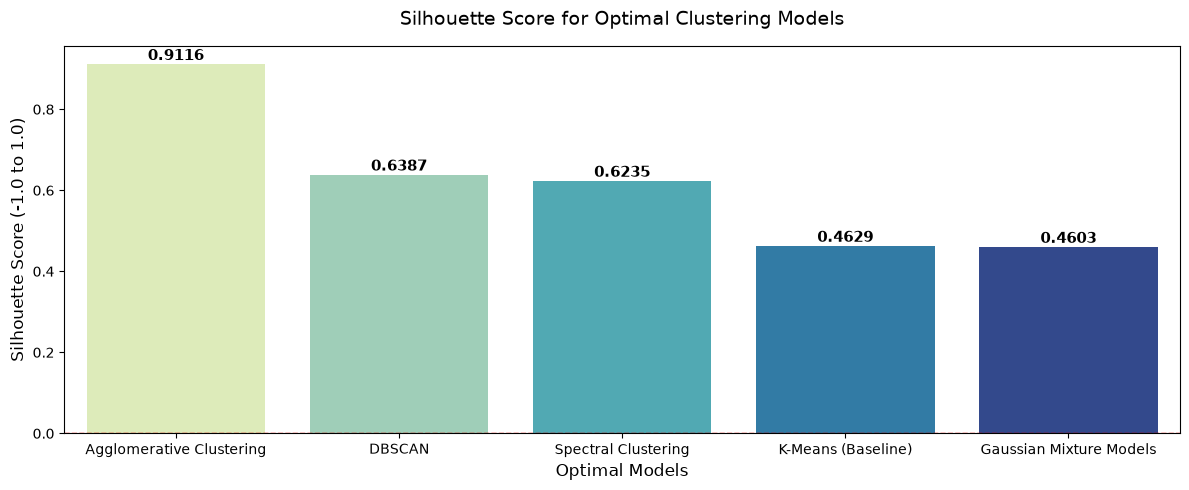

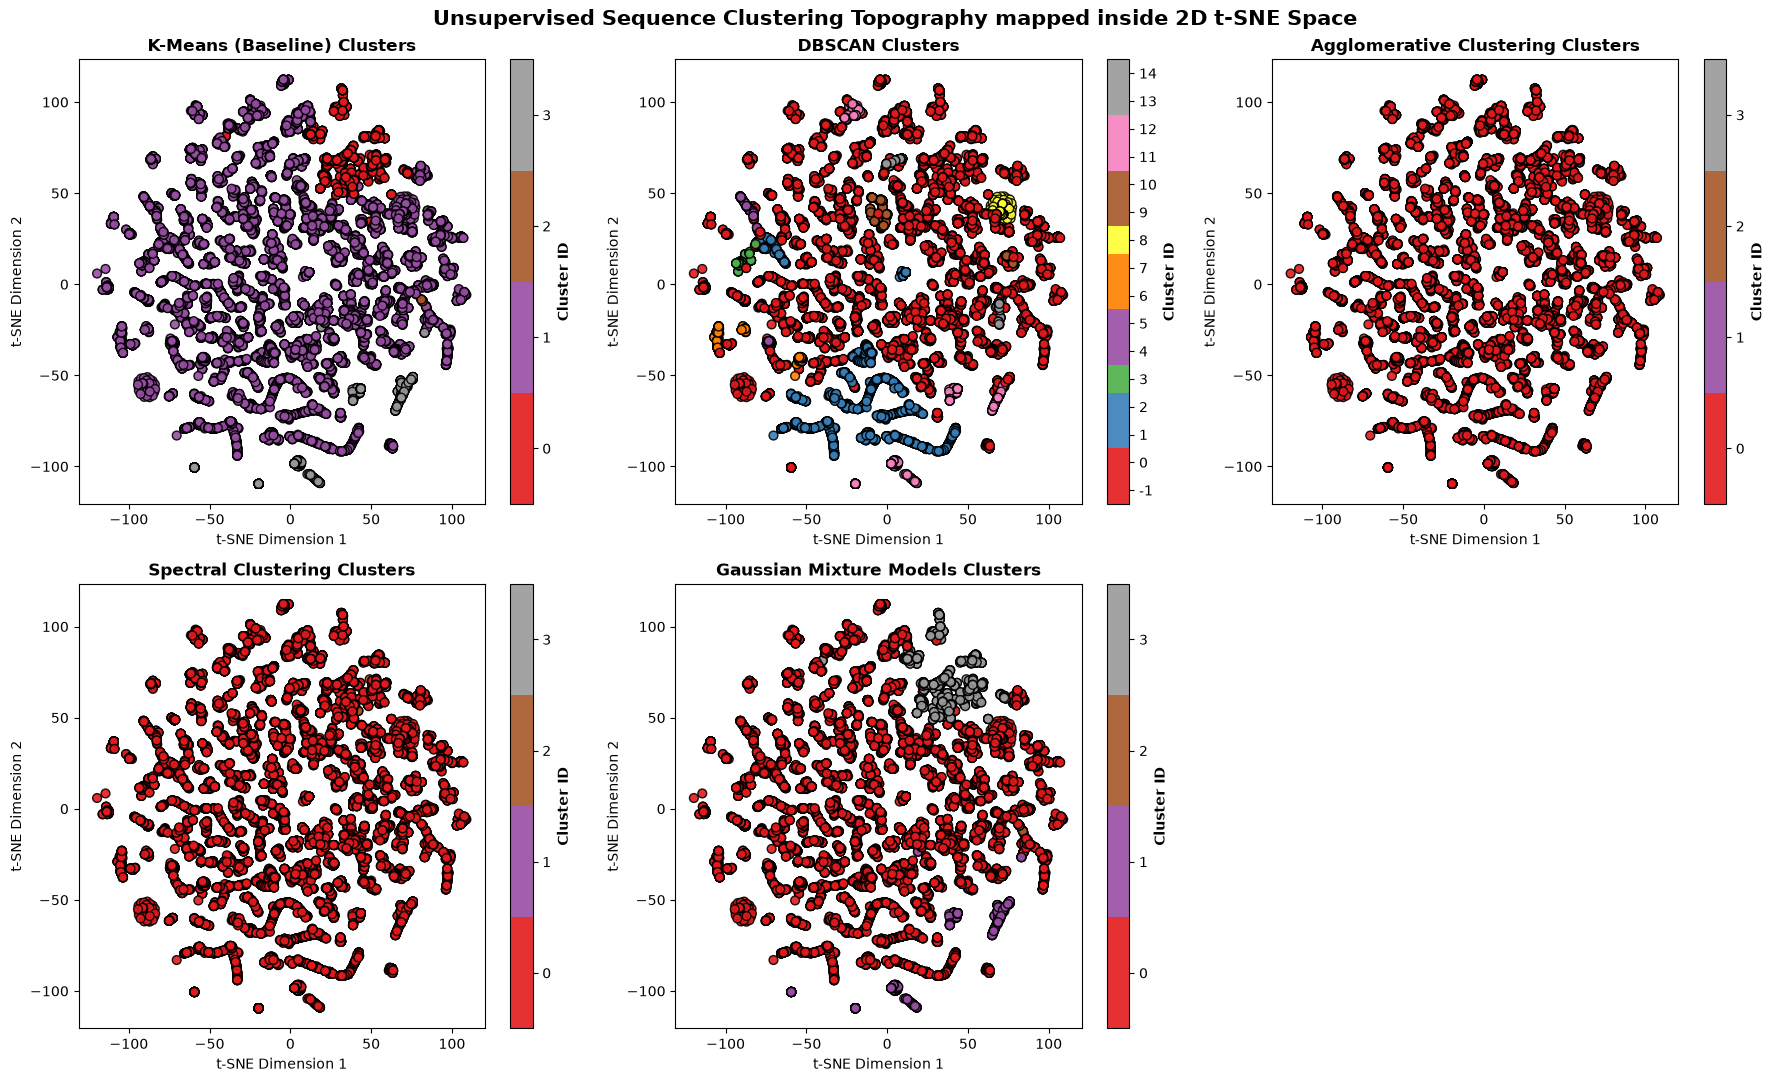

In [44]:
run_pipeline(
    df_raw=df_all,
    is_all_sequences_dataset=True, 
    should_apply_pca=False
)

## With PCA

Original number of features: 77
Updated number of features: 58

Original class distribution:
	orthohantavirus puumalaense: 3562
	orthohantavirus hantanense: 2056
	orthohantavirus dobravaense: 764
	orthohantavirus sinnombreense: 276

Resampled class distribution (after SMOTE):
	orthohantavirus puumalaense: 3562
	orthohantavirus hantanense: 3562
	orthohantavirus dobravaense: 3562
	orthohantavirus sinnombreense: 3562

Final dataset shape: X: (14248, 58), y: (14248,)

Applying PCA (target variance/components: 0.95)...
Shape before PCA: (14248, 58)
Shape after PCA: (14248, 31)
Total explained variance ratio: 0.9570

Optimal K-Means (Baseline) framework setup:
	init: k-means++
	n_init: 10
Silhouette Score: 0.4843
Davies-Bouldin Score: 1.0692
Calinski-Harabasz Score: 2466.6425


Optimal DBSCAN framework setup:
	eps: 0.2
	min_samples: 80
	metric: manhattan
Silhouette Score: 0.9060
Davies-Bouldin Score: 0.1409
Calinski-Harabasz Score: 1722112.2695


Optimal Agglomerative Clustering framework se

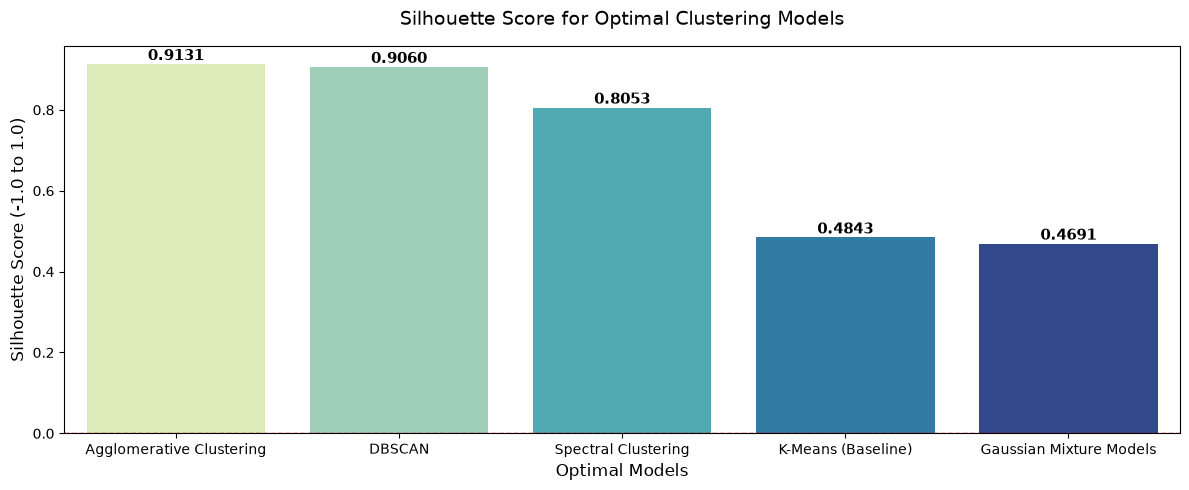

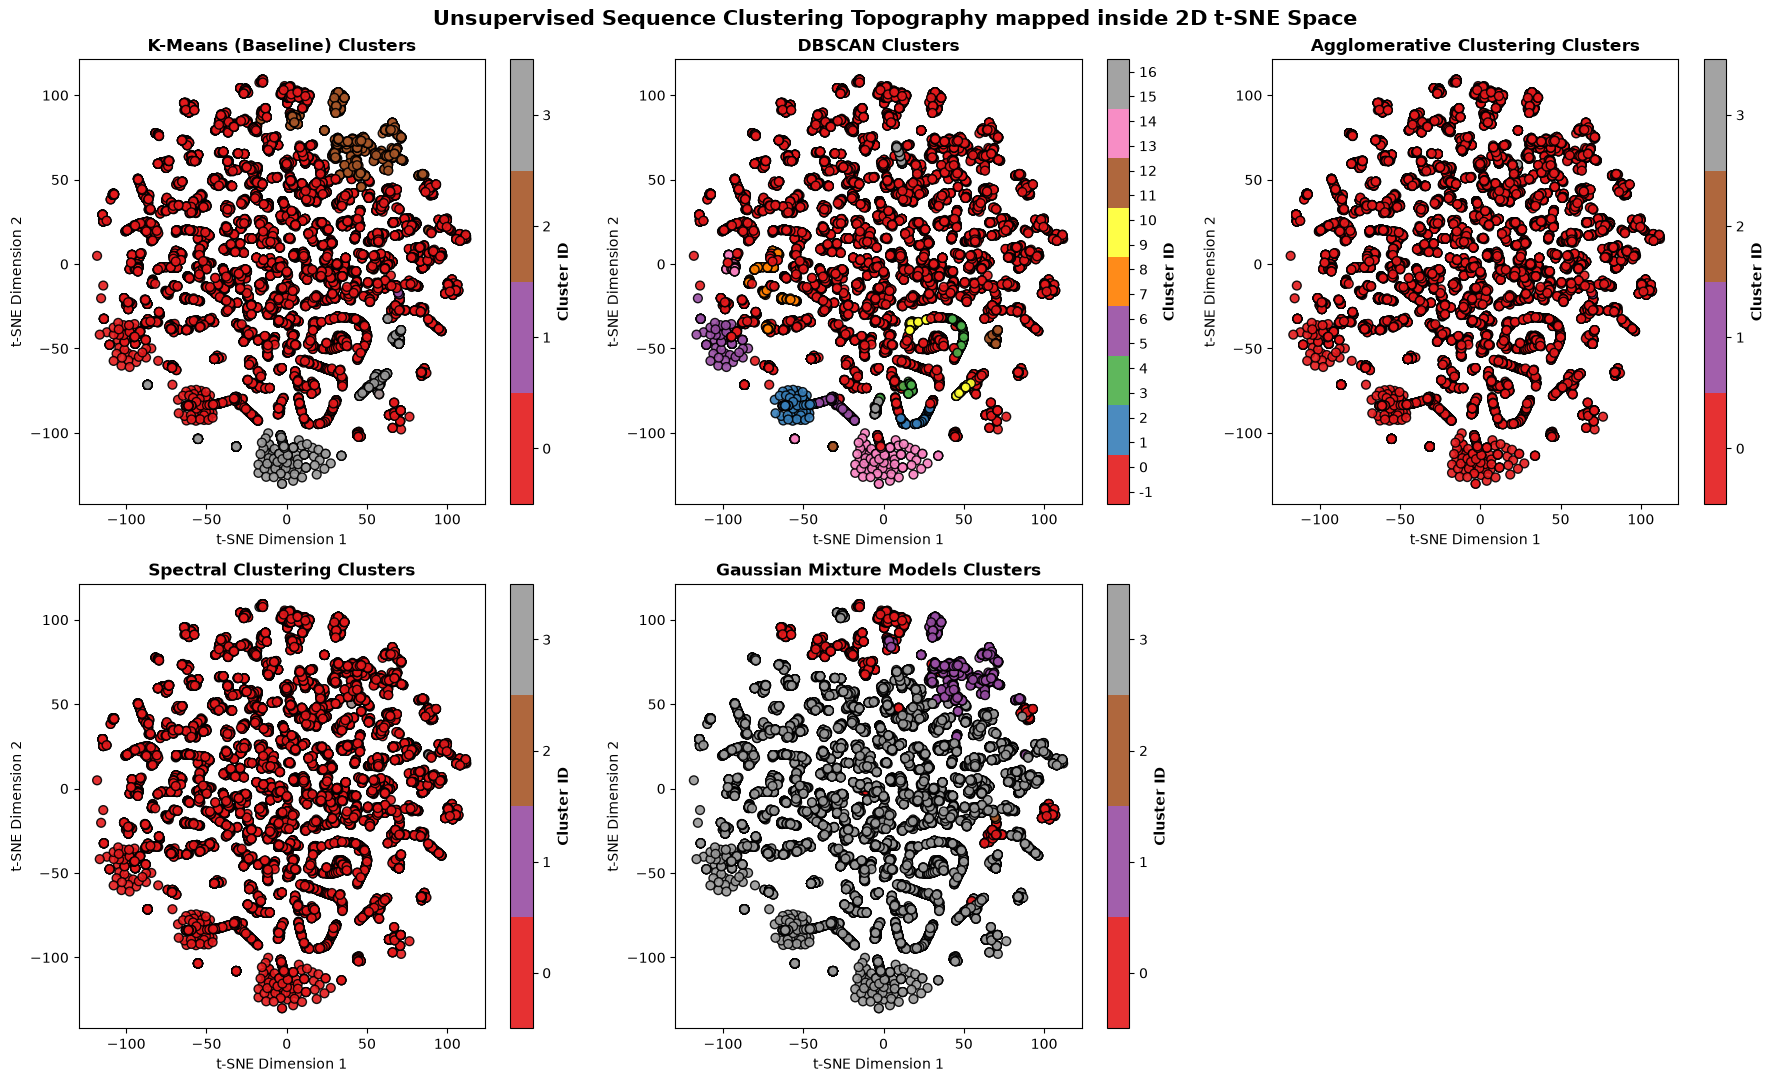

In [45]:
run_pipeline(
    df_raw=df_all,
    is_all_sequences_dataset=True, 
    should_apply_pca=True
)

# Complete sequences dataset

In [46]:
df_complete: pd.DataFrame = pd.read_csv(COMPLETE_SEQUENCES_DATASET_PATH)
df_complete.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 73 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sequence_ID     435 non-null    str    
 1   dc_total_count  435 non-null    int64  
 2   dc_avg_length   435 non-null    float64
 3   dc_max_length   435 non-null    int64  
 4   dc_len_5        435 non-null    int64  
 5   dc_len_6        435 non-null    int64  
 6   dc_len_7        435 non-null    int64  
 7   dc_len_8        435 non-null    int64  
 8   dc_len_9        435 non-null    int64  
 9   dc_len_10       435 non-null    int64  
 10  dc_len_11       435 non-null    int64  
 11  dc_len_12       435 non-null    int64  
 12  dc_len_13       435 non-null    int64  
 13  dc_len_14       435 non-null    int64  
 14  dc_len_15       435 non-null    int64  
 15  dc_len_16       435 non-null    int64  
 16  dc_len_17       435 non-null    int64  
 17  dc_len_18       435 non-null    int64  
 18  d

In [47]:
df_complete.head()

,Sequence_ID,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,...,in_len_13,in_len_14,in_len_15,in_len_16,in_len_17,in_len_18,in_len_19,in_len_23,in_len_29,Virus_Species
0,AY017064.1,264,5.340909,8,196,48,18,2,0,0,...,1,0,0,0,0,0,0,0,0,Orthohantavirus hantanense
1,AY526217.1,11591,5.379864,10,8624,1975,648,261,66,17,...,0,1,0,0,1,0,0,0,0,Orthohantavirus puumalaense
2,AY526218.1,3034,5.379038,12,2134,744,109,12,25,9,...,0,1,1,0,0,0,0,0,0,Orthohantavirus puumalaense
3,AY526219.1,526,5.161597,13,457,65,0,2,0,0,...,0,0,1,0,0,0,0,0,0,Orthohantavirus puumalaense
4,AY961615.1,378,5.174603,6,312,66,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Orthohantavirus dobravaense


In [48]:
df_complete.describe()

,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,dc_len_11,...,in_len_12,in_len_13,in_len_14,in_len_15,in_len_16,in_len_17,in_len_18,in_len_19,in_len_23,in_len_29
count,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,...,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000
mean,4555.137931,5.327800,10.747126,3422.873563,822.655172,224.443678,53.914943,23.236782,6.013793,1.425287,...,0.668966,0.542529,0.342529,0.388506,0.032184,0.041379,0.027586,0.082759,0.087356,0.002299
std,4865.822505,0.082903,2.855258,3661.914632,851.103063,262.698261,85.862336,31.763259,9.133409,2.828558,...,1.782099,0.933211,0.555582,0.660510,0.176691,0.199395,0.163973,0.275834,0.282682,0.047946
min,8.000000,5.079439,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,321.000000,5.292250,8.000000,258.500000,67.000000,16.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2678.000000,5.327492,10.000000,1986.000000,521.000000,96.000000,8.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10785.000000,5.361464,13.000000,8146.000000,1827.500000,551.000000,67.000000,64.000000,17.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,13846.000000,6.368421,18.000000,10254.000000,2628.000000,784.000000,315.000000,89.000000,28.000000,10.000000,...,11.000000,5.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Original number of features: 71
Updated number of features: 44

Original class distribution:
	orthohantavirus hantanense: 242
	orthohantavirus puumalaense: 117
	orthohantavirus dobravaense: 40
	orthohantavirus sinnombreense: 18

Resampled class distribution (after SMOTE):
	orthohantavirus hantanense: 242
	orthohantavirus puumalaense: 242
	orthohantavirus dobravaense: 242
	orthohantavirus sinnombreense: 242

Final dataset shape: X: (968, 44), y: (968,)

Optimal K-Means (Baseline) framework setup:
	init: k-means++
	n_init: 5
Silhouette Score: 0.1869
Davies-Bouldin Score: 1.8576
Calinski-Harabasz Score: 99.9457


Optimal DBSCAN framework setup:
	min_samples: 30
	metric: euclidean
Silhouette Score: 0.0000
Davies-Bouldin Score: 0.0000
Calinski-Harabasz Score: 0.0000


Optimal Agglomerative Clustering framework setup:
	linkage: average
Silhouette Score: 0.6339
Davies-Bouldin Score: 0.2561
Calinski-Harabasz Score: 11.7028


Optimal Spectral Clustering framework setup:
	affinity: rbf
	n_neighb

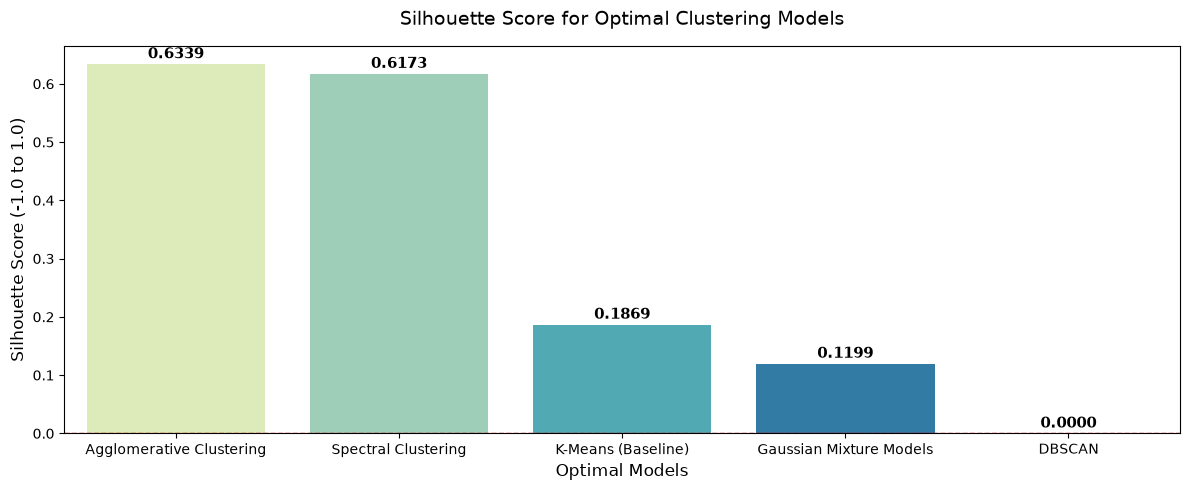

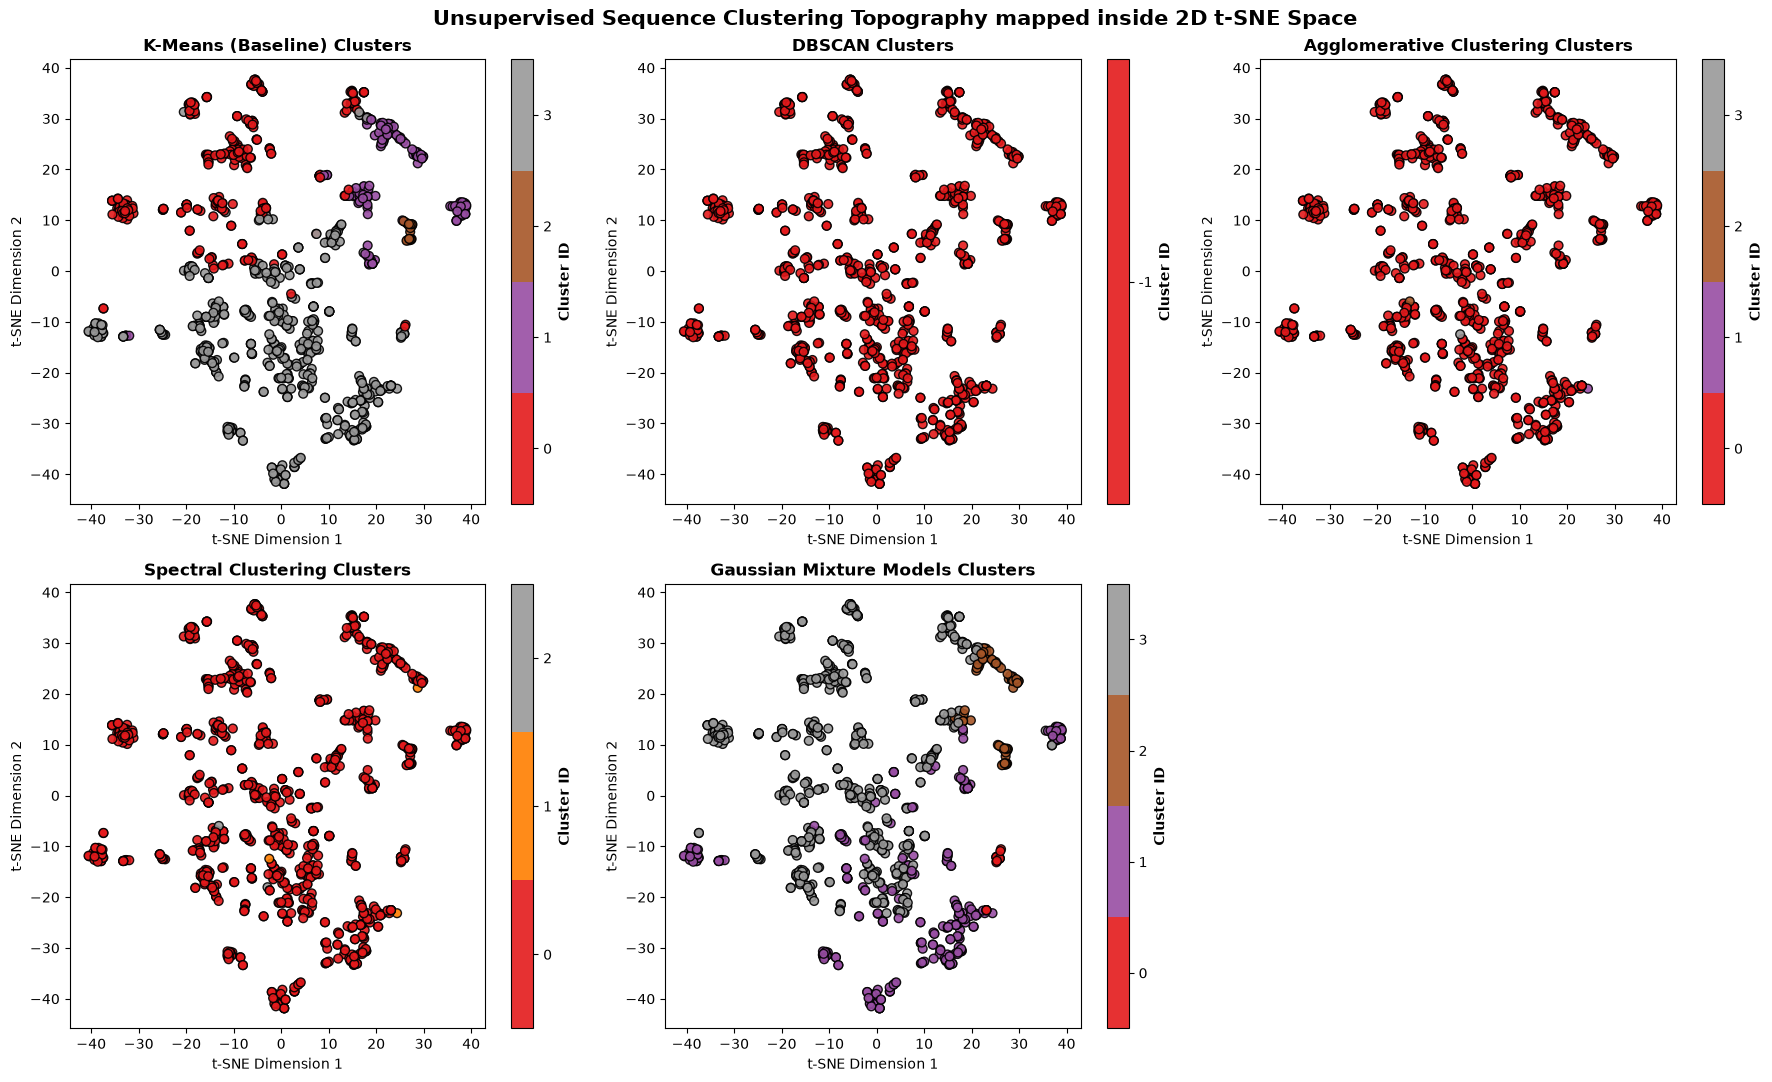

In [49]:
run_pipeline(
    df_raw=df_complete,
    is_all_sequences_dataset=False, 
    should_apply_pca=False
)

## With PCA

Original number of features: 71
Updated number of features: 44

Original class distribution:
	orthohantavirus hantanense: 242
	orthohantavirus puumalaense: 117
	orthohantavirus dobravaense: 40
	orthohantavirus sinnombreense: 18

Resampled class distribution (after SMOTE):
	orthohantavirus hantanense: 242
	orthohantavirus puumalaense: 242
	orthohantavirus dobravaense: 242
	orthohantavirus sinnombreense: 242

Final dataset shape: X: (968, 44), y: (968,)

Applying PCA (target variance/components: 4)...
Shape before PCA: (968, 44)
Shape after PCA: (968, 4)
Total explained variance ratio: 0.3464

Optimal K-Means (Baseline) framework setup:
	init: k-means++
	n_init: 5
Silhouette Score: 0.4851
Davies-Bouldin Score: 0.8588
Calinski-Harabasz Score: 635.3472


Optimal DBSCAN framework setup:
	min_samples: 30
	metric: euclidean
Silhouette Score: 0.7517
Davies-Bouldin Score: 0.2260
Calinski-Harabasz Score: 800.3796


Optimal Agglomerative Clustering framework setup:
	linkage: average
Silhouette Sc

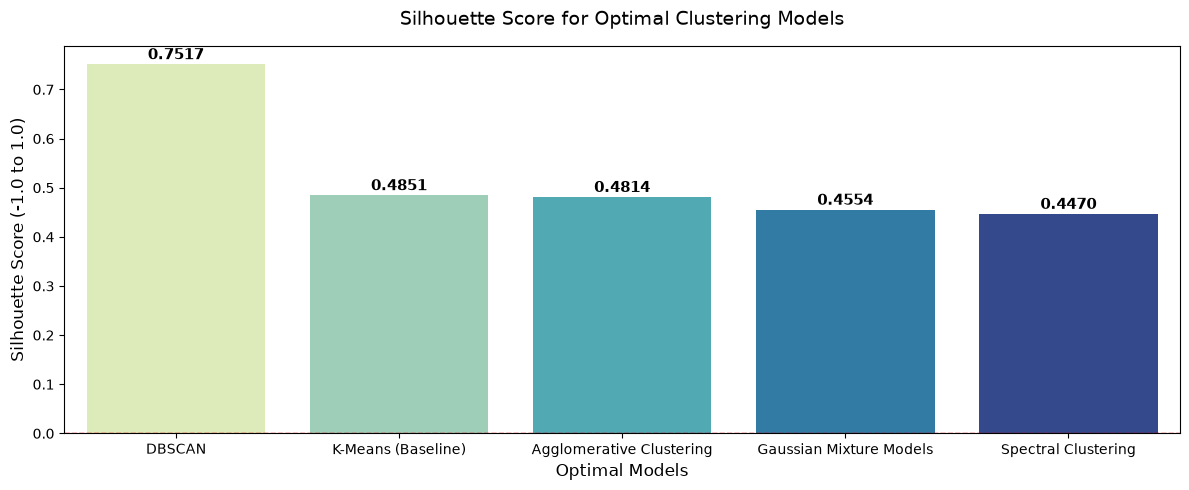

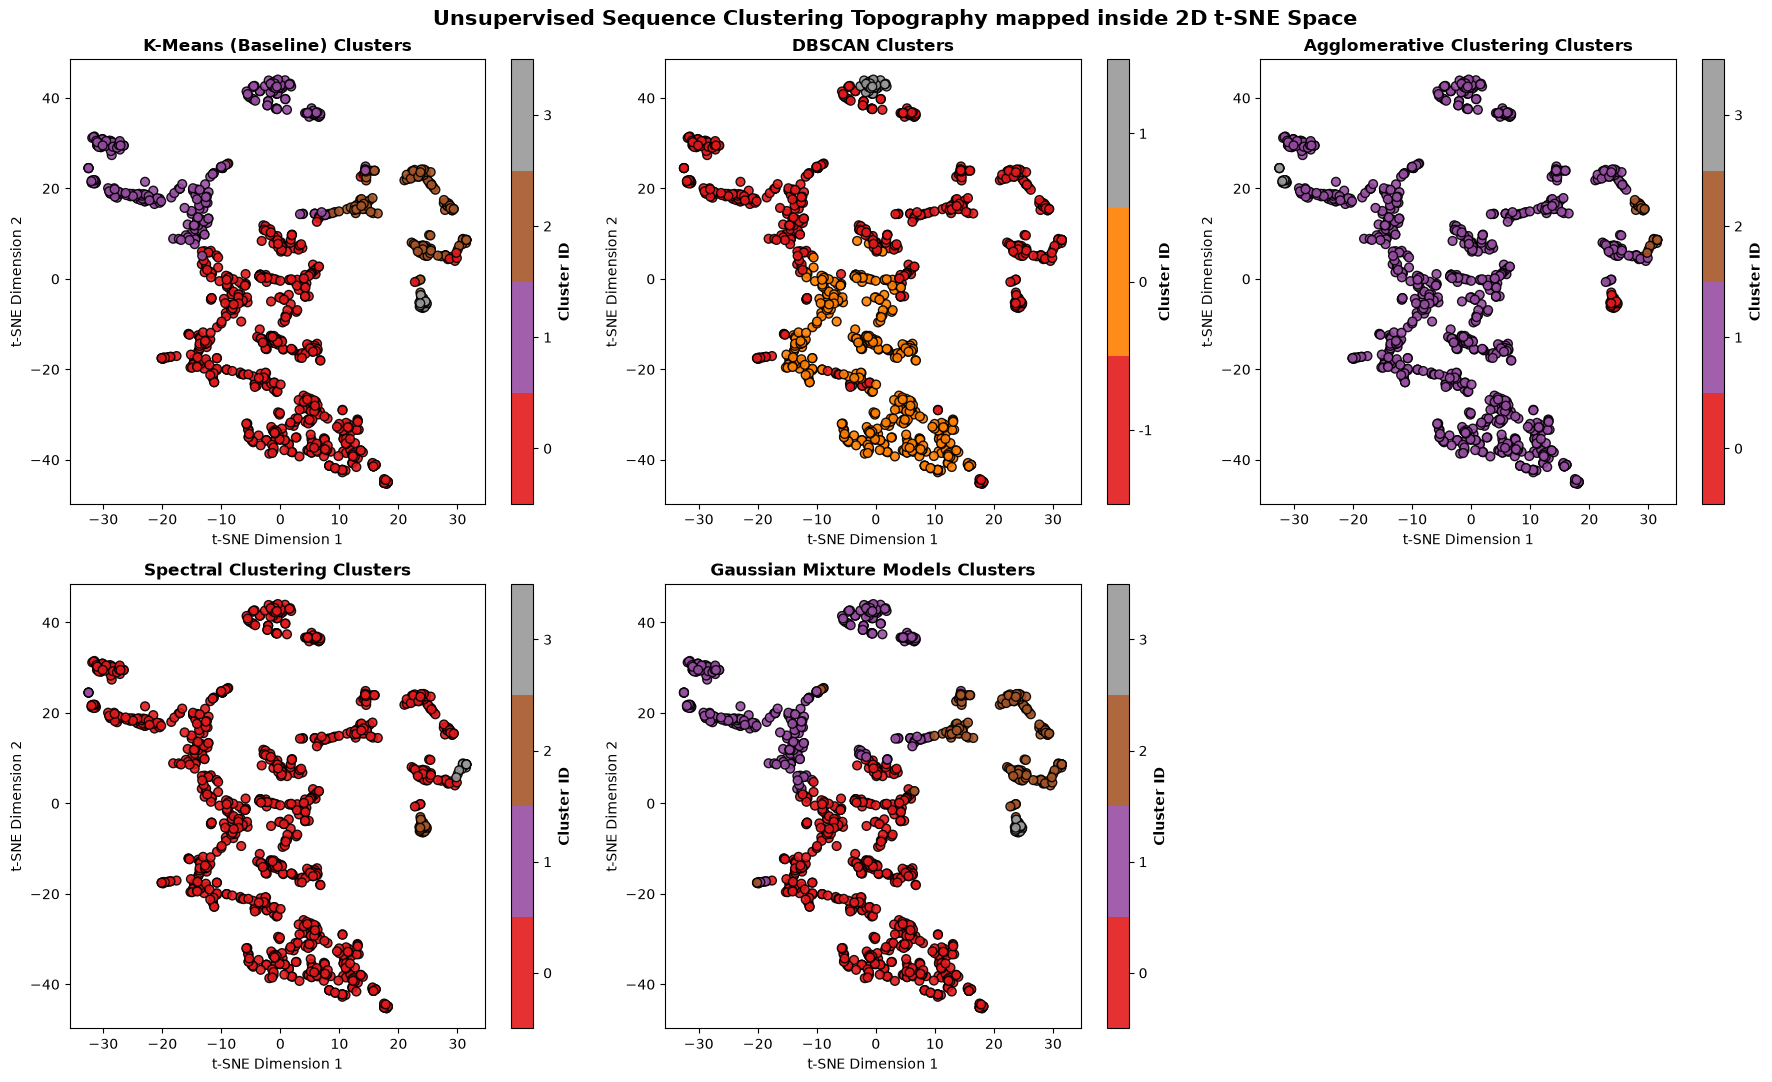

In [50]:
run_pipeline(
    df_raw=df_complete,
    is_all_sequences_dataset=False, 
    should_apply_pca=True
)